In [1]:
import sys
from pathlib import Path
# Add parent directory to path to import from src/
sys.path.append(str(Path(__file__).parent.parent) if '__file__' in globals() else str(Path.cwd().parent))

from sionna.rt import (
    load_scene, RadioMapSolver, PathSolver, Camera, transform_mesh,
    MeshRadioMap, Receiver, subcarrier_frequencies
)
from src.utils import (
    extract_building_positions_from_scene, get_antenna_positions, get_scene_bounds,
    get_tx_color, get_building_bounds, clip_terrain_to_buildings, visualize_time_frequency_response
)
from src.radio_map import filter_positions_by_edge_distance
from src.base_station import set_tx_antenna_array, add_base_station
from src.user_equipment import set_rx_antenna_array, generate_ue_parameters
from src.path_solver import get_doppler_stats, get_delay_stats
import numpy as np
import matplotlib.pyplot as plt

jitc_llvm_init(): LLVM API initialization failed ..


In [2]:
# Define parameters
CARRIER_FREQUENCY = 3.5e9  # carrier frequency in Hz
NUM_DEPLOYMENT_BUILDINGS = 6  # number of buildings to deploy base stations on
ANTENNA_HEIGHT_OFFSET = 10.0  # height offset of antennas from the roof
SCENE_CENTER = [0.0, 0.0]  # center of the scene
USER_SHIFT_FROM_GROUND = 1.5  # up shift in meters of users from the ground plane or ground mesh
CLIP_TERRAIN_TO_BUILDINGS = True  # whether to clip the terrain to building bounds
TERRAIN_CLIP_MARGIN = 15.0  # margin in meters around buildings when clipping terrain
OUTPUT_DIR_NAME = Path("./output")  # directory to save the output files
scene_dir = Path("../scenes/sf_1/")  # path to the scene directory
scene_xml_path = scene_dir / "scene.xml"  # path to the scene XML file
output_dir = OUTPUT_DIR_NAME / scene_dir.name
output_dir.mkdir(parents=True, exist_ok=True)

# TX antenna array parameters
TX_NUM_ROWS = 1  # number of rows of antennas
TX_NUM_COLS = 32  # number of columns of antennas
TX_VERTICAL_SPACING = 0.5  # vertical spacing (in units of carrier wavelength) between antennas
TX_HORIZONTAL_SPACING = 0.5  # horizontal spacing (in units of carrier wavelength) between antennas
TX_PATTERN = "tr38901"  # tx antenna pattern
TX_POLARIZATION = "V"  # polarization of the tx antennas


# Base station parameters
NUM_SECTORS = 6  # number of sectors for each base station
MECHANICAL_TILT = 10.0  # mechanical tilt of the antenna
AZIMUTH_OFFSET = 0.0  # rotate the antenna arrays around z-axis by this amount (in degrees)
TX_POWER_DBM = 43.0  # tx power in dBm for each tx antenna array
BS_DISPLAY_RADIUS = 15.0  # display radius of the sphere representing the base station when visualized


# RX antenna array parameters
RX_NUM_ROWS = 1  # number of rows of antennas
RX_NUM_COLS = 1  # number of columns of antennas
RX_DISPLAY_RADIUS = 3  # display radius of the sphere representing the receiver when visualized
RX_VERTICAL_SPACING = 0.5  # vertical spacing (in units of carrier wavelength) between antennas
RX_HORIZONTAL_SPACING = 0.5  # horizontal spacing (in units of carrier wavelength) between antennas
RX_PATTERN = "hw_dipole"  # rx antenna pattern
RX_POLARIZATION = "V"  # polarization of the rx antennas


# Radio map solver parameters
RADIO_MAP_SPECULAR_REFLECTION = True  # whether to include specular reflection
RADIO_MAP_DIFFUSE_REFLECTION = True  # whether to include diffuse reflection
RADIO_MAP_REFRACTION = True  # whether to include refraction
RADIO_MAP_DIFFRACTION = True  # whether to include diffraction
RADIO_MAP_EDGE_DIFFRACTION = True  # whether to include edge diffraction
RADIO_MAP_DIFFRACTION_LIT_REGION = False  # whether to include diffraction in the lit region
RADIO_MAP_MAX_DEPTH = 5  # maximum number of ray scene interactions
RADIO_MAP_SAMPLES_PER_TX = 10**8  # number of samples per tx antenna array

# Path solver parameters
PATH_SOLVER_MAX_DEPTH = 5  # maximum number of ray scene interactions
PATH_SOLVER_MAX_NUM_PATHS_PER_SRC = 10**6  # maximum number of paths per source
PATH_SOLVER_SAMPLES_PER_SRC = 10**6  # number of samples per source
PATH_SOLVER_SYNTHETIC_ARRAY = True  # use synthetic array for path computation
PATH_SOLVER_LOS_MODE = True  # include line-of-sight paths
PATH_SOLVER_SPECULAR_REFLECTION = True  # include specular reflections
PATH_SOLVER_DIFFUSE_REFLECTION = True  # include diffuse reflections
PATH_SOLVER_REFRACTION = True  # include refraction
PATH_SOLVER_DIFFRACTION = True  # include diffraction
PATH_SOLVER_EDGE_DIFFRACTION = True  # include edge diffraction
PATH_SOLVER_DIFFRACTION_LIT_REGION = False  # include diffraction in lit region
PATH_SOLVER_SEED = 1  # seed for reproducibility
PATH_SOLVER_PER_TX_USERS_ONLY = False  # if True, solve paths only for users associated with each TX; if False, solve for all users (but still per TX)

# user sampling parameters
NUM_USER_SAMPLES_PER_TX = 1000  # number of user samples to generate
USER_SAMPLE_SEED = 1  # seed for the user sampling
USER_SAMPLE_MIN_VAL_DB = -150  # minimum value in dB for the user sampling
USER_SAMPLE_MAX_VAL_DB = 0  # maximum value in dB for the user sampling (no sampling above this)
USER_SAMPLE_MIN_DIST = 0.0  # minimum distance in meters from TX for the user sampling
USER_SAMPLE_MAX_DIST = 10000.0  # maximum distance in meters from TX for the user sampling (10 km)
USER_SAMPLE_METRIC = "path_gain"  # metric for the user sampling
TX_ASSOCIATION = True  # whether to use tx association for the user sampling
SAMPLE_CENTER_POS = True  # whether sample the user sampling from the radio map cell center, if True, the user is located at the center of the cell
SCENE_EDGE_EPSILON = 1  # minimum distance in meters from scene edges to keep users (0.0 means no filtering)

# User equipment mobility presets
# Each preset defines: orientation_mode, speed_distribution, direction_mode, and optional speed params
MOBILITY_PRESETS = {
    "stationary": {
        "orientation_mode": "random",  # "random" or "to_tx"
        "speed_distribution": None,
    },
    "stationary_to_tx": {
        "orientation_mode": "to_tx",
        "speed_distribution": None,
    },
    "pedestrian": {
        "orientation_mode": "random",
        "speed_distribution": "pedestrian",  # 0.5-2 m/s
        "direction_mode": "random",
    },
    "pedestrian_to_tx": {
        "orientation_mode": "to_tx",
        "speed_distribution": "pedestrian",
        "direction_mode": "random",
    },
    "vehicular": {
        "orientation_mode": "random",
        "speed_distribution": "vehicular",  # 8-30 m/s
        "direction_mode": "random",
    },
    "slow_walking": {
        "orientation_mode": "random",
        "speed_distribution": "uniform_continuous",
        "speed_min": 0.5,
        "speed_max": 1.5,
        "direction_mode": "random",
    },
    "fast_walking": {
        "orientation_mode": "random",
        "speed_distribution": "uniform_continuous",
        "speed_min": 1.5,
        "speed_max": 2.5,
        "direction_mode": "random",
    },
}
MOBILITY_PRESET = "vehicular"  # select preset to use

# OFDM parameters
NUM_SUBCARRIERS = 32  # number of subcarriers
NUM_OFDM_SYMBOLS = 14  # number of OFDM symbols
SUBCARRIER_SPACING = 30e3  # spacing between subcarriers in Hz
# Channel Frequency Response (CFR) parameters
CFR_NORMALIZE_DELAYS = True  # whether to normalize delays in CFR computation
CFR_NORMALIZE = False  # whether to normalize the CFR
CFR_OUT_TYPE = "numpy"  # output type for CFR ("numpy" or "tensorflow")

In [3]:
ofdm_symbol_duration = 1 / SUBCARRIER_SPACING

# merge_shapes=False prevents the building walls and roofs from being merged into a single object
scene = load_scene(scene_xml_path, merge_shapes=False) 

# set carrier frequency
scene.frequency = CARRIER_FREQUENCY

# get the bounding box of the scene
# used to position the camera only
_, bbox_max = get_scene_bounds(scene)

# Detect if elevation data is present by checking the lidar_terrain.ply file
lidar_terrain_path = scene_dir / "mesh" / "lidar_terrain.ply"  # this file does not exist if lidar elevation data is not present
has_elevation = lidar_terrain_path.exists()

# Extract building positions from the loaded scene object (needed for clipping and antenna placement)
building_positions = extract_building_positions_from_scene(scene)

# Optionally clip terrain to building bounds BEFORE creating measurement surface
if CLIP_TERRAIN_TO_BUILDINGS and has_elevation:
    bounds = get_building_bounds(building_positions)
    if bounds:
        (min_x, min_y), (max_x, max_y) = bounds
        print(f"Building bounds: x=[{min_x:.1f}, {max_x:.1f}], y=[{min_y:.1f}, {max_y:.1f}]")
        clip_terrain_to_buildings(scene, building_positions, margin=TERRAIN_CLIP_MARGIN)

# Now create measurement surface from (potentially clipped) terrain
if has_elevation:
    terrain_obj = scene.objects.get("ground")
    if terrain_obj:
        measurement_surface = terrain_obj.clone(as_mesh=True)
        transform_mesh(measurement_surface, translation=[0,0,USER_SHIFT_FROM_GROUND])
    else:
        measurement_surface = None
else:
    measurement_surface = None

# get the antenna positions for deployment buildings
antenna_information = get_antenna_positions(
    building_positions, 
    scene_center=SCENE_CENTER,
    antenna_height_offset=ANTENNA_HEIGHT_OFFSET,
    num_deployment_buildings=NUM_DEPLOYMENT_BUILDINGS)

2026-02-10 02:03:03 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Building bounds: x=[-341.7, 381.1], y=[-521.2, 322.2]


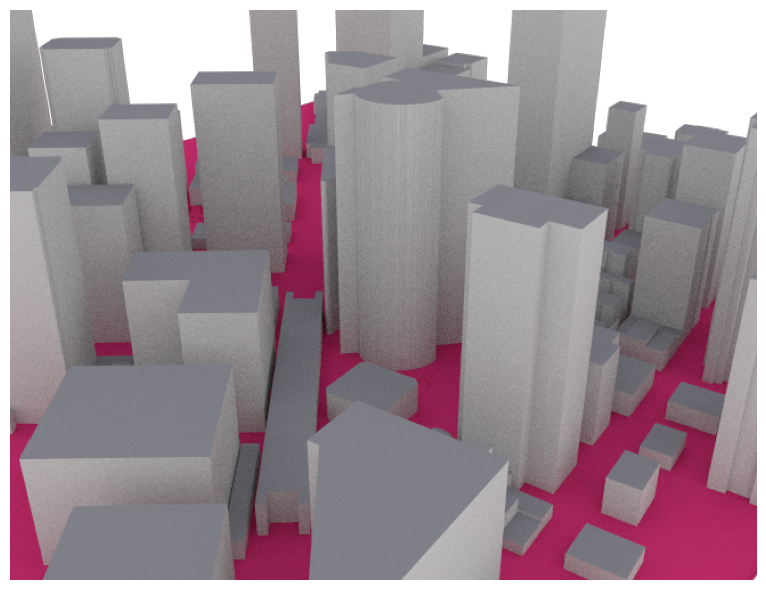

In [4]:
# Position the camera at a good viewing distance from the scene center and look at the scene center
camera = Camera(position=bbox_max, look_at=[0, 0, 0])
scene.render(camera=camera);
# it might be a good idea to save the scene picture for debugging purposes
_ = scene.render_to_file(filename=f"{output_dir}/scene.png", camera=camera)

In [5]:
# set tx and rx specs and add base stations
set_tx_antenna_array(
    scene,
    num_rows=TX_NUM_ROWS,
    num_cols=TX_NUM_COLS,
    vertical_spacing=TX_VERTICAL_SPACING,
    horizontal_spacing=TX_HORIZONTAL_SPACING,
    pattern=TX_PATTERN,
    polarization=TX_POLARIZATION)

# For radio map solver, receive antenna array params are assumed fixed
# and modifying them does not matter. See below from the Sionna RT technical report:
# The receive antenna pattern is not applied here. Instead, the squared norm of the
# electric field is used. This is equivalent to assuming that a receiver positioned
# on the measurement plane uses a dual-polarized isotropic antenna, and that both components are combined non-coherently.
# Therefore, the following line is needed for Path Solver not Radio Map Solver
set_rx_antenna_array(
    scene,
    num_rows=RX_NUM_ROWS,
    num_cols=RX_NUM_COLS,
    vertical_spacing=RX_VERTICAL_SPACING,
    horizontal_spacing=RX_HORIZONTAL_SPACING,
    pattern=RX_PATTERN,
    polarization=RX_POLARIZATION
)

# add base stations
for i, current_antenna_information in enumerate(antenna_information):
    bs_name = f"BS_{i}"
    _, antenna_position = current_antenna_information
    print(f"Adding base station {bs_name} at position {antenna_position}")
    add_base_station(
        scene,
        bs_name,
        position=antenna_position,
        num_sectors=NUM_SECTORS,
        mechanical_tilt=MECHANICAL_TILT,
        azimuth_offset=AZIMUTH_OFFSET,
        tx_power_dbm=TX_POWER_DBM,
        display_radius=BS_DISPLAY_RADIUS
    )

Adding base station BS_0 at position [140.2479248046875, -247.82835388183594, 336.0]
Adding base station BS_1 at position [272.8895568847656, -268.2861328125, 254.39999389648438]
Adding base station BS_2 at position [-122.80189514160156, 17.523963928222656, 222.0]
Adding base station BS_3 at position [194.66702270507812, -188.2830810546875, 204.0]
Adding base station BS_4 at position [108.48082733154297, -168.91168212890625, 193.0]
Adding base station BS_5 at position [3.406595468521118, 25.890933990478516, 192.0]


In [6]:
rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               measurement_surface=measurement_surface,
               specular_reflection=RADIO_MAP_SPECULAR_REFLECTION,
               diffuse_reflection=RADIO_MAP_DIFFUSE_REFLECTION,
               refraction=RADIO_MAP_REFRACTION,
               diffraction=RADIO_MAP_DIFFRACTION,
               edge_diffraction=RADIO_MAP_EDGE_DIFFRACTION,
               diffraction_lit_region=RADIO_MAP_DIFFRACTION_LIT_REGION,
               max_depth=RADIO_MAP_MAX_DEPTH,
               samples_per_tx=RADIO_MAP_SAMPLES_PER_TX)

In [7]:
if isinstance(rm, MeshRadioMap):
    scene.preview(radio_map=rm, rm_db_scale=True, rm_metric="path_gain");

In [9]:
tx_association = rm.tx_association(metric="path_gain").numpy()
valid_association_mask = tx_association != -1
print(f"Percentage of cells with coverage: {np.sum(valid_association_mask) / len(valid_association_mask) * 100:.2f}%")

Percentage of cells with coverage: 79.85%


In [10]:
sampled_positions = rm.sample_positions(
    num_pos=NUM_USER_SAMPLES_PER_TX,
    metric=USER_SAMPLE_METRIC,
    min_val_db=USER_SAMPLE_MIN_VAL_DB,
    max_val_db=USER_SAMPLE_MAX_VAL_DB,
    min_dist=USER_SAMPLE_MIN_DIST,
    max_dist=USER_SAMPLE_MAX_DIST,
    tx_association=TX_ASSOCIATION,
    center_pos=SAMPLE_CENTER_POS,
    seed=USER_SAMPLE_SEED
)

In [11]:
# Filter positions to remove users close to measurement surface edges
sampled_positions = filter_positions_by_edge_distance(
    sampled_positions,
    edge_epsilon=SCENE_EDGE_EPSILON
)

In [12]:
# first index for the positions vs. cell id
# second index for the tx id
# third index for the position id
print(sampled_positions[0][0][0]) # print the position of the tx=0, user=0 for that tx.
print(sampled_positions[1][0][0]) # print the cell_id of the tx=0, user=0 for that tx.

[ 302.46848   -162.22528      1.6033335]
815


In [13]:
# sampled_positions[0] = positions tensor [num_tx, num_users_per_tx, 3]
# sampled_positions[1] = cell_ids tensor [num_tx, num_users_per_tx]
# Convert to numpy once for efficient iteration
positions = sampled_positions[0]  # shape: [num_tx, num_users_per_tx, 3]
cell_ids = sampled_positions[1]   # shape: [num_tx, num_users_per_tx]

num_txs, num_users_per_tx, _ = positions.shape
total_users = num_txs * num_users_per_tx
print(f"Total TXs: {num_txs}, Users per TX: {num_users_per_tx}, Total users: {total_users}")

# Get config from selected preset and generate UE parameters
preset_config = MOBILITY_PRESETS[MOBILITY_PRESET]
orientation_mode = preset_config.get("orientation_mode", "random")

orientations, velocities = generate_ue_parameters(
    num_ues=total_users,
    seed=USER_SAMPLE_SEED,
    **preset_config
)

# Add receivers for each user
user_count = 0
for tx_idx in range(num_txs):
    # Map tx_idx to TX name: BS_{bs_id}_sector_{sector_id}
    bs_id = tx_idx // NUM_SECTORS
    sector_id = (tx_idx % NUM_SECTORS) + 1
    tx_name = f"BS_{bs_id}_sector_{sector_id}"
    
    # Get the TX object from the scene (needed for look_at mode)
    tx_object = scene.get(tx_name)
    
    # Color for this TX's users (for visualization purposes)
    color = get_tx_color(tx_idx, num_txs)
    
    for user_idx in range(num_users_per_tx):
        pos = positions[tx_idx, user_idx].tolist()  # [x, y, z]
        vel = velocities[user_count].tolist()       # [vx, vy, vz]
        
        if orientation_mode == "random":
            rx = Receiver(
                name=f"UE_{user_count}",
                position=pos,
                orientation=orientations[user_count].tolist(),
                velocity=vel,
                color=color
            )
        else:  # "to_tx"
            rx = Receiver(
                name=f"UE_{user_count}",
                position=pos,
                look_at=tx_object,
                velocity=vel,
                color=color
            )
        
        scene.add(rx)
        user_count += 1

print(f"Added {user_count} receivers to scene")
print(f"  - Preset: {MOBILITY_PRESET}")
print(f"  - Orientation: {orientation_mode}, Speed: {preset_config.get('speed_distribution')}")

Total TXs: 36, Users per TX: 225, Total users: 8100
Added 8100 receivers to scene
  - Preset: vehicular
  - Orientation: random, Speed: vehicular


In [14]:
if isinstance(rm, MeshRadioMap):
    scene.preview();

In [ ]:
# PathSolver is computationally expensive, so we solve for each TX separately
# Note: Paths objects cannot be saved/loaded, so they must be solved each time
ps = PathSolver()

# Get all receivers and TXs from scene
all_rx_names = [obj for obj in scene.receivers]
all_tx_names = [obj for obj in scene.transmitters]

# Calculate receiver indices per TX
# Receivers are named UE_0, UE_1, ..., UE_{total_users-1}
# TX 0: UE_0 to UE_{num_users_per_tx-1}
# TX 1: UE_{num_users_per_tx} to UE_{2*num_users_per_tx-1}
# etc.
paths_per_tx = []

for tx_idx in range(num_txs):
    # Map tx_idx to TX name
    bs_id = tx_idx // NUM_SECTORS
    sector_id = (tx_idx % NUM_SECTORS) + 1
    tx_name = f"BS_{bs_id}_sector_{sector_id}"

    # Determine which receivers to use for this TX
    if PATH_SOLVER_PER_TX_USERS_ONLY:
        # Only use receivers that are associated with this TX (based on highestpath gain computed by Radio Map Solver)
        start_idx = tx_idx * num_users_per_tx
        end_idx = (tx_idx + 1) * num_users_per_tx
        selected_rx_names = all_rx_names[start_idx:end_idx]
        print(f"TX {tx_idx} ({tx_name}): Solving paths for {len(selected_rx_names)} associated users (UE_{start_idx} to UE_{end_idx-1})")
    else:
        # Use all receivers
        selected_rx_names = all_rx_names
        print(f"TX {tx_idx} ({tx_name}): Solving paths for all {len(selected_rx_names)} users")

    # Temporarily remove other receivers and TXs from scene
    rx_names_to_remove = [name for name in all_rx_names if name not in selected_rx_names]
    tx_names_to_remove = [name for name in all_tx_names if name != tx_name]
    
    # Store removed objects so we can restore them later
    removed_rxs = []
    removed_txs = []

    # Remove receivers from both scene.objects and scene.receivers
    for rx_name_to_remove in rx_names_to_remove:
        removed_rxs.append(scene.get(rx_name_to_remove))
        scene.remove(rx_name_to_remove)
    
    # Remove TXs from both scene.objects and scene.transmitters
    for tx_name_to_remove in tx_names_to_remove:
        removed_txs.append(scene.get(tx_name_to_remove))
        scene.remove(tx_name_to_remove)
    
    try:
        print(f"Solving paths for TX {tx_idx} ({tx_name}) with {len(selected_rx_names)} receivers")
        print(f"Scene receivers: {len(scene.receivers)}")
        print(f"Scene transmitters: {len(scene.transmitters)}")
        # Solve paths for this TX with selected receivers
        paths_tx = ps(
            scene,
            max_depth=PATH_SOLVER_MAX_DEPTH,
            max_num_paths_per_src=PATH_SOLVER_MAX_NUM_PATHS_PER_SRC,
            samples_per_src=PATH_SOLVER_SAMPLES_PER_SRC,
            synthetic_array=PATH_SOLVER_SYNTHETIC_ARRAY,
            los=PATH_SOLVER_LOS_MODE,
            specular_reflection=PATH_SOLVER_SPECULAR_REFLECTION,
            diffuse_reflection=PATH_SOLVER_DIFFUSE_REFLECTION,
            refraction=PATH_SOLVER_REFRACTION,
            diffraction=PATH_SOLVER_DIFFRACTION,
            edge_diffraction=PATH_SOLVER_EDGE_DIFFRACTION,
            diffraction_lit_region=PATH_SOLVER_DIFFRACTION_LIT_REGION,
            seed=PATH_SOLVER_SEED
        )
        paths_per_tx.append(paths_tx)
        
    finally:
        # Restore removed receivers and TXs
        for rx_obj in removed_rxs:
            scene.add(rx_obj)
        for tx_obj in removed_txs:
            scene.add(tx_obj)

print(f"\nCompleted path solving for {len(paths_per_tx)} TXs")


In [ ]:
# compute doppler stats per tx
mean_doppler_shifts, doppler_spreads, min_max_doppler_shifts = get_doppler_stats(paths_per_tx)

for tx_idx, (mean_doppler_shift, doppler_spread, min_max_doppler_shift) in enumerate(zip(mean_doppler_shifts, doppler_spreads, min_max_doppler_shifts)):
    d_min, d_max = float(min_max_doppler_shift[0]), float(min_max_doppler_shift[1])
    print(f"TX {tx_idx}: Mean Doppler Shift: {mean_doppler_shift:.4f}, Doppler Spread: {doppler_spread:.4f}, Min–Max Doppler: {d_min:.2f} – {d_max:.2f} Hz")

# compute delay stats per tx (delays in seconds; display in ns for readability)
# Counts: reasonable = in-range (used for stats), unreasonable = negative or >max, padding = zero/empty; total = reasonable + unreasonable
print("paths.tau shape (TX 0):", paths_per_tx[0].tau.numpy().shape)
(mean_delays, delay_spreads, rms_delay_spreads, min_max_delays,
 num_reasonable_delays, num_unreasonable_delays, num_padding_delays, num_total_delays) = get_delay_stats(paths_per_tx)
SEC_TO_NANO = 1e9

for tx_idx, (mean_delay, delay_spread, rms_delay_spread, min_max_delay,
             n_reasonable, n_unreasonable, n_padding, n_total) in enumerate(zip(
    mean_delays, delay_spreads, rms_delay_spreads, min_max_delays,
    num_reasonable_delays, num_unreasonable_delays, num_padding_delays, num_total_delays
)):
    mean_ns = mean_delay * SEC_TO_NANO if np.isfinite(mean_delay) else mean_delay
    spread_ns = delay_spread * SEC_TO_NANO if np.isfinite(delay_spread) else delay_spread
    rms_ns = rms_delay_spread * SEC_TO_NANO if np.isfinite(rms_delay_spread) else rms_delay_spread
    min_max_ns = (min_max_delay[0] * SEC_TO_NANO if np.isfinite(min_max_delay[0]) else min_max_delay[0],
                  min_max_delay[1] * SEC_TO_NANO if np.isfinite(min_max_delay[1]) else min_max_delay[1])
    print(f"TX {tx_idx}: reasonable {n_reasonable} + unreasonable {n_unreasonable} = total {n_total} (padding {n_padding}) | Mean: {mean_ns:.2f} ns, Spread: {spread_ns:.2f} ns, RMS: {rms_ns:.2f} ns, Min–Max: {min_max_ns[0]:.2f}–{min_max_ns[1]:.2f} ns")


In [ ]:
# Compute CFR for each TX and combine results
frequencies = subcarrier_frequencies(NUM_SUBCARRIERS, SUBCARRIER_SPACING)
# Final shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_ofdm_symbols, num_subcarriers]
cfr_per_tx = []

for tx_idx, paths_tx in enumerate(paths_per_tx):
    # Compute CFR for this TX
    h_tx = paths_tx.cfr(
        frequencies=frequencies,
        sampling_frequency=1/ofdm_symbol_duration,
        num_time_steps=NUM_OFDM_SYMBOLS,
        normalize_delays=CFR_NORMALIZE_DELAYS,
        normalize=CFR_NORMALIZE,
        out_type=CFR_OUT_TYPE
    )
    cfr_per_tx.append(h_tx)
    print(f"TX {tx_idx}: CFR shape {h_tx.shape}")

# print dimensions
num_rxs, num_rx_ant, num_txs, num_tx_ant, num_ofdm_symbols, num_subcarriers = cfr_per_tx[0].shape
print(f"\nCFR shape from PathSolver: [num_users={num_rxs}, num_tx={num_txs}, num_rx_ant={num_rx_ant}, num_tx_ant={num_tx_ant}, num_subcarriers={num_subcarriers}, num_ofdm_symbols={num_ofdm_symbols}]")

In [ ]:
# visualize time-frequency response of a channel between a TX antenna and a RX antenna

sample_tx_idx = 3
sample_rx_idx = 20
sample_tx_ant_idx = 0
sample_rx_ant_idx = 0

sample_tx_rx_cfr = cfr_per_tx[sample_tx_idx][sample_rx_idx,sample_rx_ant_idx,0,sample_tx_idx,:,:]
# Visualize selected channel
fig = visualize_time_frequency_response(sample_tx_rx_cfr, title="First User Channel (TX=0, RX_ant=0, TX_ant=0)")
plt.show()

In [ ]:
# Apply an FFTshift to bring subcarriers in the
# correct order for an IFFT
h = np.fft.fftshift(sample_tx_rx_cfr, axes=1)

# Apply IFFT to subcarrier dimension to
# convert frequency to delay domain
h_delay = np.fft.ifft(h, axis=1, norm="ortho")

# Apply FFT to time-step dimension to
# convert time to Doppler domain
h_delay_doppler = np.fft.fft(h_delay, axis=0, norm="ortho")

# Apply FFTShift to bring Doppler dimension in the correct
# order for visualization
h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0)

# Plot raw delay-Doppler response
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(np.abs(h_delay_doppler), 
               aspect='auto', 
               origin='lower',
               cmap='viridis',
               interpolation='nearest')
ax.set_xlabel('Delay (subcarrier index)', fontsize=12)
ax.set_ylabel('Doppler (OFDM symbol index)', fontsize=12)
ax.set_title('Raw Delay-Doppler Response', fontsize=14)
plt.colorbar(im, ax=ax, label='Magnitude')
plt.tight_layout()
plt.show()


In [ ]:
# Test inverse transform: recover CFR from delay-Doppler domain

# Step 1: Reverse the fftshift on Doppler dimension
h_delay_doppler_unshifted = np.fft.ifftshift(h_delay_doppler, axes=0)

# Step 2: Apply IFFT to time dimension to convert Doppler → time
h_delay_recovered = np.fft.ifft(h_delay_doppler_unshifted, axis=0, norm="ortho")

# Step 3: Apply FFT to subcarrier dimension to convert delay → frequency
# Note: We need to reverse the initial fftshift that was applied before IFFT
h_recovered = np.fft.fft(h_delay_recovered, axis=1, norm="ortho")
cfr_recovered = np.fft.ifftshift(h_recovered, axes=1)  # Reverse the initial fftshift

# Compare with original CFR
error = np.abs(cfr_recovered - sample_tx_rx_cfr)
max_error = np.max(error)
mean_error = np.mean(error)

print(f"Reconstruction error:")
print(f"  Max error: {max_error:.2e}")
print(f"  Mean error: {mean_error:.2e}")
print(f"  Relative max error: {max_error / (np.max(np.abs(sample_tx_rx_cfr)) + 1e-10):.2e}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original CFR
im1 = axes[0].imshow(np.abs(sample_tx_rx_cfr), 
                     aspect='auto', 
                     origin='lower',
                     cmap='viridis',
                     interpolation='nearest')
axes[0].set_xlabel('Subcarrier index', fontsize=11)
axes[0].set_ylabel('OFDM symbol index', fontsize=11)
axes[0].set_title('Original CFR', fontsize=12)
plt.colorbar(im1, ax=axes[0], label='Magnitude')

# Recovered CFR
im2 = axes[1].imshow(np.abs(cfr_recovered), 
                     aspect='auto', 
                     origin='lower',
                     cmap='viridis',
                     interpolation='nearest')
axes[1].set_xlabel('Subcarrier index', fontsize=11)
axes[1].set_ylabel('OFDM symbol index', fontsize=11)
axes[1].set_title('Recovered CFR', fontsize=12)
plt.colorbar(im2, ax=axes[1], label='Magnitude')

# Error
im3 = axes[2].imshow(error, 
                     aspect='auto', 
                     origin='lower',
                     cmap='hot',
                     interpolation='nearest')
axes[2].set_xlabel('Subcarrier index', fontsize=11)
axes[2].set_ylabel('OFDM symbol index', fontsize=11)
axes[2].set_title(f'Reconstruction Error\n(max: {max_error:.2e})', fontsize=12)
plt.colorbar(im3, ax=axes[2], label='Absolute Error')

plt.tight_layout()
plt.show()

# Check if reconstruction is successful (error should be very small, close to numerical precision)
if max_error < 1e-10:
    print("Perfect reconstruction! Error is within numerical precision.")
else:
    print(f"Warning: Reconstruction error is larger than expected ({max_error:.2e})")